# Model Selection 

## Banking camping for fixed deposit with the customer data 

Problem statement 


For this demonstration, you will use the bank marketing data set. So, let’s try and understand the problem statement to utilise the information available in the best possible way and proceed in the right direction as per the business problem at hand.

So, a bank ran a marketing campaign in the past and has obtained data pertaining to nearly 11,000 customers, which includes variables such as their age, jobs, bank balance, education, loan status and so on. Based on this data, the bank wants to develop its future strategies based on the insights that it drew from the previous campaign and improve for the next campaign so that more customers agree to open term deposits with the bank.

Hence, ‘deposit’ is the target variable here. A ‘Yes’ in the ‘deposit’ column indicates that the campaign was successful and the customer agreed to open a term deposit account with the bank. In contrast, a ‘No’ in the ‘deposit’ column indicates that the campaign was not very successful and the customer could not be convinced to open a term deposit account.

Essentially, the bank wants to:

Build a model that quantitatively relates to the success of the marketing campaign with variables such as job, marital status, education, bank balance, etc.
Identify the features of the data set that affect the successful conversion of customers.
To know the accuracy of the model, i.e., how well these variables predict the success of the campaign.

### Lets import the required libraries 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
#import numpy as np, pandas as pd
#import matplotlib.pyplot as plt, seaborn as sns
from IPython.core.display import display, HTML
display(HTML("<style>.container {width:100% !important;}</style>"))
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

C:\Users\HP\AppData\Local\Temp\ipykernel_26792\512250070.py:3: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


#### Lets read the data file 

In [ ]:
df = pd.read_csv(r"bank marketing v2.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,poutcome,deposit,p_recency
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,unknown,yes,NaN
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,unknown,yes,NaN
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,unknown,yes,NaN
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,unknown,yes,NaN
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,unknown,yes,NaN


In [4]:
df['marital'].value_counts()

marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

In [5]:
df.shape

(11162, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  poutcome   11162 non-null  object
 13  deposit    11162 non-null  object
 14  p_recency  2838 non-null   object
dtypes: int64(4), object(11)
memory usage: 1.3+ MB


In [7]:
df.value_counts()

age  job         marital  education  default  balance  housing  loan  contact   day  month  duration  poutcome  deposit  p_recency
18   student     single   primary    no       608      no       no    cellular  13   nov    210       success   yes      a_6m         1
45   admin.      married  secondary  no       1097     yes      yes   cellular  2    feb    174       failure   no       b_1yr        1
     management  married  tertiary   no       0        yes      no    cellular  5    may    469       failure   no       b_1yr        1
                                              160      no       no    cellular  10   nov    182       success   yes      b_1yr        1
                                              226      yes      no    cellular  13   aug    177       success   yes      a_6m         1
                                                                                                                                     ..
34   management  married  tertiary   no       303    

In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'poutcome', 'deposit',
       'p_recency'],
      dtype='object')

In [9]:
df.isnull().sum()

age             0
job             0
marital         0
education       0
default         0
balance         0
housing         0
loan            0
contact         0
day             0
month           0
duration        0
poutcome        0
deposit         0
p_recency    8324
dtype: int64

In [10]:
df.describe()

,age,balance,day,duration
count,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818
std,11.913369,3225.413326,8.420740,347.128386
min,18.000000,-6847.000000,1.000000,2.000000
25%,32.000000,122.000000,8.000000,138.000000
50%,39.000000,550.000000,15.000000,255.000000
75%,49.000000,1708.000000,22.000000,496.000000
max,95.000000,81204.000000,31.000000,3881.000000


#### We can pick  the target column which is deposit 

In [11]:
df.deposit.value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [12]:
df.deposit.isnull().sum()

0

In [13]:
5873+5289

11162

#### Lets convert the categorical values Yes and No on deposit column

In [14]:
df['deposit'].value_counts(dropna=False)

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [15]:
df.deposit

0        yes
1        yes
2        yes
3        yes
4        yes
        ... 
11157    yes
11158     no
11159    yes
11160    yes
11161    yes
Name: deposit, Length: 11162, dtype: object

In [16]:
df['deposit'] = df['deposit'].str.strip().str.lower().map({'yes':1, 'no':0})
df.deposit

0        1
1        1
2        1
3        1
4        1
        ..
11157    1
11158    0
11159    1
11160    1
11161    1
Name: deposit, Length: 11162, dtype: int64

In [17]:
df.deposit.value_counts()

deposit
0    5873
1    5289
Name: count, dtype: int64

In [18]:
df.deposit.value_counts(normalize = True)

deposit
0    0.52616
1    0.47384
Name: proportion, dtype: float64

### Lets collect all the categorical

In [19]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'p_recency'],
      dtype='object')

#### Lets the normalize value for all the columns using pair plots

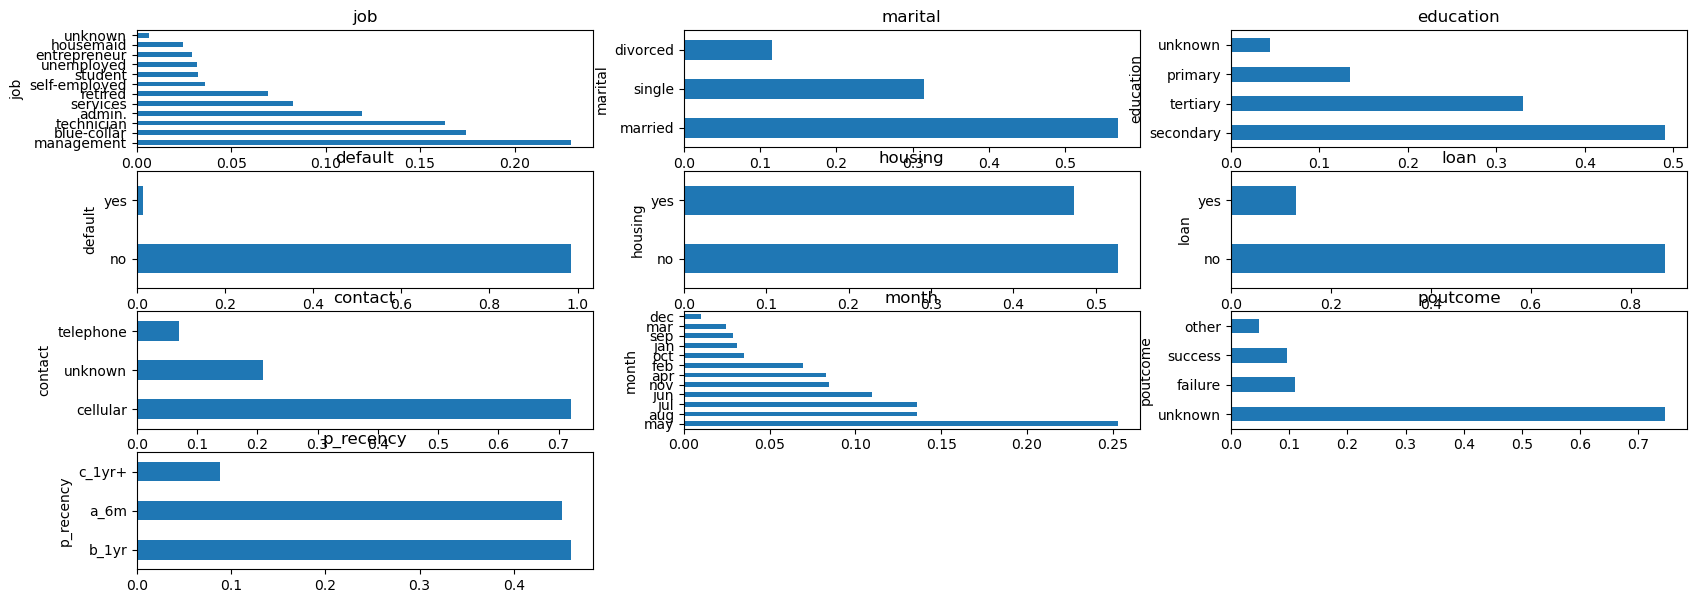

In [20]:
plt.figure(figsize = [20,7])
for ind, col in enumerate (cat_cols):
    plt.subplot(4,3, ind+1)
    df[col].value_counts(normalize=True).plot.barh()
    plt.title(col)
plt.show()

In [21]:
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

#### Lets create all the numerical columns togeather 

In [22]:
num_cols = df.select_dtypes(int).columns
num_cols

Index(['age', 'balance', 'day', 'duration', 'deposit'], dtype='object')

##### Lets drop the Day and Duration columns as they will not give you much details on our model 

In [23]:
df1 = df.drop(['day', 'duration'],axis=1)
df1.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'deposit', 'p_recency'],
      dtype='object')

In [24]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   month      11162 non-null  object
 10  poutcome   11162 non-null  object
 11  deposit    11162 non-null  int64 
 12  p_recency  2838 non-null   object
dtypes: int64(3), object(10)
memory usage: 1.1+ MB


In [25]:
num_cols = df1.select_dtypes('number').columns
num_cols

Index(['age', 'balance', 'deposit'], dtype='object')

#### Lets drop the deposit columns as this is our target Variable 

In [26]:
num_cols = num_cols.drop(['deposit'])
num_cols

Index(['age', 'balance'], dtype='object')

### Lets see the normalize score on both the variables 

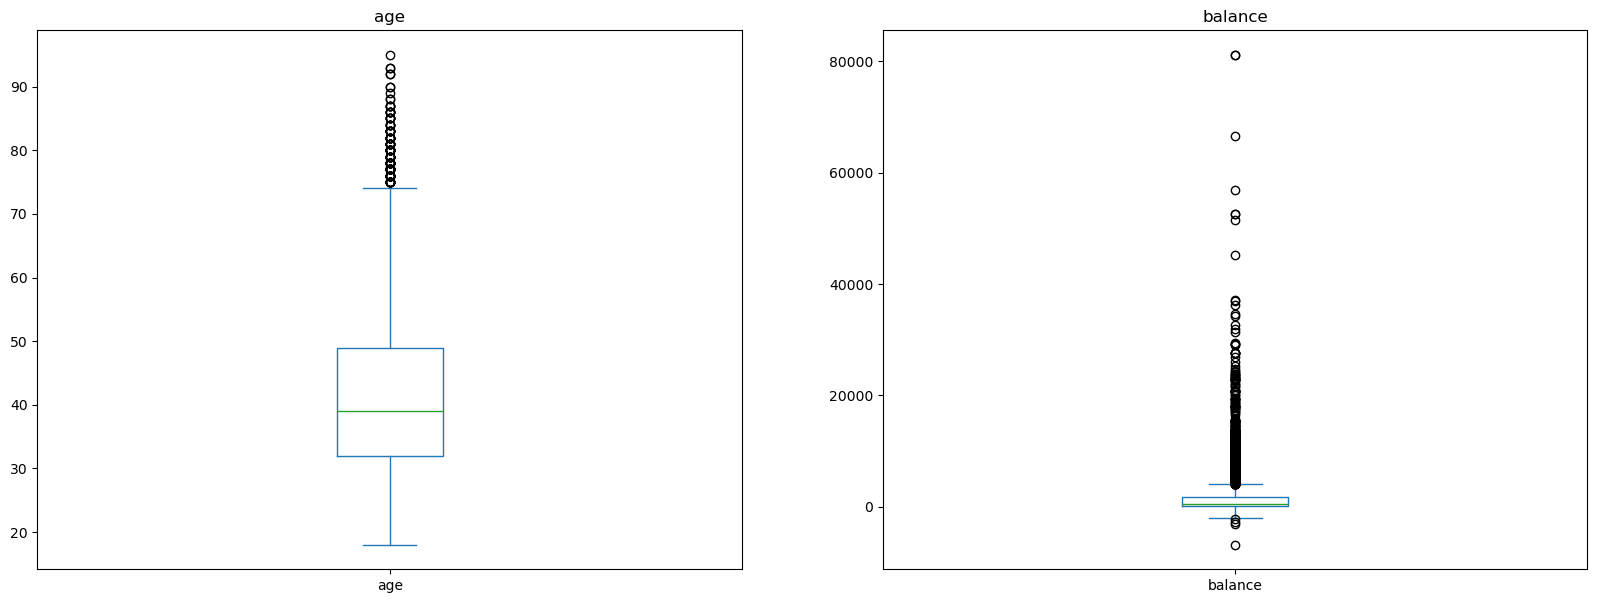

In [27]:
plt.figure(figsize = [20,7])
for ind, col in enumerate (num_cols):
    plt.subplot(1,2, ind+1)
    df1[col].plot.box()
    plt.title(col)
plt.show()

### Now lets create a function to convert few categorical variable into numerical variable 

In [28]:
def binary_map(col):
    return col.map({"yes": 1, 'no':0}) 

##### lets convert the columns Default, Loan & Housing as these columns has the values Yes & No

In [29]:
binary_cols = ['default', 'loan', 'housing']
binary_cols

['default', 'loan', 'housing']

In [30]:
df1[binary_cols] = df1[binary_cols].apply(binary_map)
df1.housing.value_counts()

housing
0    5881
1    5281
Name: count, dtype: int64

In [31]:
df1.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'deposit', 'p_recency'],
      dtype='object')

In [32]:
df1.head()

,age,job,marital,education,default,balance,housing,loan,contact,month,poutcome,deposit,p_recency
0,59,admin.,married,secondary,0,2343,1,0,unknown,may,unknown,1,NaN
1,56,admin.,married,secondary,0,45,0,0,unknown,may,unknown,1,NaN
2,41,technician,married,secondary,0,1270,1,0,unknown,may,unknown,1,NaN
3,55,services,married,secondary,0,2476,1,0,unknown,may,unknown,1,NaN
4,54,admin.,married,tertiary,0,184,0,0,unknown,may,unknown,1,NaN


##### Creating Dummy features for rest of the columns 
##### Education, Marital, P_recency, contact, poutcome, job, month
##### As all the mentioned columns has more than 2 values - so doing FE by dropping the 1st value 
##### Lets see how to do that

In [33]:
dum_cols = ['education', 'marital', 'p_recency', 'contact', 'poutcome', 'job', 'month']
dum_cols

['education', 'marital', 'p_recency', 'contact', 'poutcome', 'job', 'month']

In [34]:
df_dumcols = pd.get_dummies(df1[dum_cols], drop_first=True).astype(int)
df_dumcols.head()

,education_secondary,education_tertiary,education_unknown,marital_married,marital_single,p_recency_b_1yr,p_recency_c_1yr+,contact_telephone,contact_unknown,poutcome_other,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
1,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,0,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [35]:
df_dumcols.shape

(11162, 34)

#### Now lets concat the df_dumcols with df1 to have the updated numeric data set 
#### so to do that 1st we need to drop the existing columns on which we just did FE 
#### So lets drop the dumcols from the dataframe df1

In [36]:
df1.drop(dum_cols,axis=1,inplace=True)

In [37]:
df1.shape

(11162, 6)

### concat the df_dumcols with df1

In [38]:
df2 = pd.concat([df1,df_dumcols], axis = 1)
df2.head()

,age,default,balance,housing,loan,deposit,education_secondary,education_tertiary,education_unknown,marital_married,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,0,2343,1,0,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
1,56,0,45,0,0,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,41,0,1270,1,0,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,55,0,2476,1,0,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,54,0,184,0,0,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0


In [39]:
df2.shape

(11162, 40)

In [40]:
df2.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'deposit',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'marital_married', 'marital_single', 'p_recency_b_1yr',
       'p_recency_c_1yr+', 'contact_telephone', 'contact_unknown',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep'],
      dtype='object')

In [41]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  11162 non-null  int64
 1   default              11162 non-null  int64
 2   balance              11162 non-null  int64
 3   housing              11162 non-null  int64
 4   loan                 11162 non-null  int64
 5   deposit              11162 non-null  int64
 6   education_secondary  11162 non-null  int32
 7   education_tertiary   11162 non-null  int32
 8   education_unknown    11162 non-null  int32
 9   marital_married      11162 non-null  int32
 10  marital_single       11162 non-null  int32
 11  p_recency_b_1yr      11162 non-null  int32
 12  p_recency_c_1yr+     11162 non-null  int32
 13  contact_telephone    11162 non-null  int32
 14  contact_unknown      11162 non-null  int32
 15  poutcome_other       11162 non-null  int32
 16  poutcome_success     1

### So now we have all the columns with the numeric values (-- You can see above--)

### Divide the data set into train and test set 

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
df_train, df_test = train_test_split(df2,  test_size = 0.2, random_state=42, stratify = df2.deposit)

In [44]:
df_train.shape, df_test.shape

((8929, 40), (2233, 40))

In [45]:
df_train.deposit.value_counts(normalize=True)

deposit
0    0.526151
1    0.473849
Name: proportion, dtype: float64

In [46]:
df_test.deposit.value_counts(normalize=True)

deposit
0    0.526198
1    0.473802
Name: proportion, dtype: float64

In [47]:
df_train.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'deposit',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'marital_married', 'marital_single', 'p_recency_b_1yr',
       'p_recency_c_1yr+', 'contact_telephone', 'contact_unknown',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep'],
      dtype='object')

In [48]:
df_test.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'deposit',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'marital_married', 'marital_single', 'p_recency_b_1yr',
       'p_recency_c_1yr+', 'contact_telephone', 'contact_unknown',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep'],
      dtype='object')

#### Now lets do the minmax scaler 

In [49]:
from sklearn.preprocessing import MinMaxScaler 

In [50]:
scaler = MinMaxScaler()

#### Lets do the minmax scaler for the numeric variables which is age and balance as these both are the integer data type

In [51]:
df_train[['age','balance']].describe()

,age,balance
count,8929.000000,8929.000000
mean,41.198790,1520.609811
std,11.865935,3062.472471
min,18.000000,-6847.000000
25%,32.000000,121.000000
50%,39.000000,550.000000
75%,49.000000,1728.000000
max,95.000000,81204.000000


#### We do fit_transform in the training set and apply that in our test set just using transform NOT fit_transform

In [52]:
df_train[['age','balance']] = scaler.fit_transform(df_train[['age','balance']])

In [53]:
df_train[['age','balance']].describe()

,age,balance
count,8929.000000,8929.000000
mean,0.301283,0.095031
std,0.154103,0.034781
min,0.000000,0.000000
25%,0.181818,0.079136
50%,0.272727,0.084008
75%,0.402597,0.097387
max,1.000000,1.000000


In [54]:
df_test[['age','balance']] = scaler.transform(df_test[['age','balance']])

In [55]:
df_test[['age','balance']].describe()

,age,balance
count,2233.000000,2233.000000
mean,0.303435,0.095482
std,0.157181,0.043254
min,0.000000,0.046961
25%,0.181818,0.079227
50%,0.272727,0.084133
75%,0.402597,0.096342
max,0.961039,1.000000


### Now lets move to the Building Predictive models 

In [56]:
X_train = df_train.drop('deposit', axis=1)
y_train = df_train['deposit']
X_test = df_test.drop('deposit', axis=1)
y_test = df_test['deposit']

#### Lets check the shape of the Train and Test 

In [57]:
X_train.shape, y_train.shape

((8929, 39), (8929,))

In [58]:
X_test.shape, y_test.shape

((2233, 39), (2233,))

### Lets begin with Logistic Regression model 

#### Lets import the logistic regression required library 

In [59]:
from sklearn.linear_model import LogisticRegression

##### Lets instantiate the model 

In [60]:
logreg = LogisticRegression(random_state=42)

In [61]:
logreg.fit(X_train,y_train)

LogisticRegression(random_state=42)

##### Lets try to evaulate the model by seeing the accuaracy on the train data 

In [62]:
y_train_pred = logreg.predict(X_train)

##### Lets import the required libraries 

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [64]:
accuracy_score(y_train, y_train_pred)

0.710829880165752

In [65]:
confusion_matrix(y_train, y_train_pred)

array([[3914,  784],
       [1798, 2433]], dtype=int64)

In [66]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.69      0.83      0.75      4698
           1       0.76      0.58      0.65      4231

    accuracy                           0.71      8929
   macro avg       0.72      0.70      0.70      8929
weighted avg       0.72      0.71      0.71      8929



#### Lets see the performance on the test set 

In [67]:
y_test_pred = logreg.predict(X_test)

In [68]:
accuracy_score(y_test, y_test_pred)

0.6950291088222122

In [69]:
confusion_matrix(y_test, y_test_pred)

array([[968, 207],
       [474, 584]], dtype=int64)

In [70]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.67      0.82      0.74      1175
           1       0.74      0.55      0.63      1058

    accuracy                           0.70      2233
   macro avg       0.70      0.69      0.69      2233
weighted avg       0.70      0.70      0.69      2233



## Now let's try our data set using Random Forest 

##### Lets import the required libraries 

In [71]:
from sklearn.ensemble import RandomForestClassifier 

In [72]:
rf = RandomForestClassifier(random_state=42, n_estimators=50, oob_score=True)

In [73]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, oob_score=True, random_state=42)

##### Performance on the Training set **

In [74]:
y_train_pred  = rf.predict(X_train)

In [75]:
accuracy_score(y_train,y_train_pred)

0.9980960913876133

In [76]:
confusion_matrix(y_test, y_test_pred)

array([[968, 207],
       [474, 584]], dtype=int64)

### lets check the accuracy on the test set 

In [77]:
y_test_pred = rf.predict(X_test)

In [78]:
accuracy_score(y_test, y_test_pred)

0.6918943125839677

## Model Evaluation using Cross Validation 

In [79]:
from sklearn.model_selection import cross_val_score

In [80]:
?cross_val_score

Signature:
cross_val_score(
    estimator,
    X,
    y=None,
    *,
    groups=None,
    scoring=None,
    cv=None,
    n_jobs=None,
    verbose=0,
    fit_params=None,
    params=None,
    pre_dispatch='2*n_jobs',
    error_score=nan,
)
Docstring:
Evaluate a score by cross-validation.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
estimator : estimator object implementing 'fit'
    The object to use to fit the data.

X : {array-like, sparse matrix} of shape (n_samples, n_features)
    The data to fit. Can be for example a list, or an array.

y : array-like of shape (n_samples,) or (n_samples, n_outputs),             default=None
    The target variable to try to predict in the case of
    supervised learning.

groups : array-like of shape (n_samples,), default=None
    Group labels for the samples used while splitting the dataset into
    train/test set. Only used in conjunction with a "Group" :term:`cv`
    instance (e.g., :class:`GroupKFold`).

    .

In [81]:
cross_val_score(logreg, X_train, y_train, cv = 5, n_jobs=-1)

array([0.70492721, 0.72284434, 0.70492721, 0.70548712, 0.70588235])

In [82]:
cross_val_score(logreg, X_train, y_train, cv = 5, n_jobs=-1).mean()

0.7088136486397472

In [83]:
cross_val_score(rf, X_train, y_train, cv = 5, n_jobs=-1)

array([0.68141097, 0.71724524, 0.69092945, 0.68085106, 0.69635854])

In [84]:
cross_val_score(rf, X_train, y_train, cv = 5, n_jobs=-1).mean()

0.6933590547081094

#### NOTES - CV score give you the reliable estimation of the generalized performance on the unseen data 

#### NOTES - OOB Score in the Random Forest is some what similar to the cross validation score 

In [85]:
rf.oob_score_

0.6901108746780155

### Scoreing method using Cross Validation 

In [86]:
?cross_val_socre

Object `cross_val_socre` not found.


In [87]:
import sklearn

In [88]:
from sklearn.metrics import get_scorer

In [89]:
cross_val_score(rf, X_train, y_train, cv = 5, n_jobs=-1, scoring = 'recall')

array([0.60047281, 0.6572104 , 0.63120567, 0.61393152, 0.62411348])

# Feature selection

### Recursive Feature Elimination - RFE 

In [90]:
from sklearn.feature_selection import RFE

In [91]:
logreg = LogisticRegression(random_state=42)

In [92]:
rfe = RFE(estimator = logreg, n_features_to_select= 10)

In [93]:
rfe.fit(X_train, y_train)

RFE(estimator=LogisticRegression(random_state=42), n_features_to_select=10)

In [94]:
rfe.ranking_

array([30, 26,  1,  5,  7, 17, 16, 18, 13, 25, 14,  1, 10,  1, 20,  1, 15,
       29, 23, 19, 22, 11, 21, 28,  1, 27, 12,  6,  4,  1,  9,  1,  3, 24,
        1,  8,  2,  1,  1])

In [95]:
rfe.support_

array([False, False,  True, False, False, False, False, False, False,
       False, False,  True, False,  True, False,  True, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False,  True, False,  True, False, False,  True, False,
       False,  True,  True])

In [96]:
X_train.columns[rfe.support_]

Index(['balance', 'p_recency_c_1yr+', 'contact_unknown', 'poutcome_success',
       'job_student', 'month_dec', 'month_jan', 'month_mar', 'month_oct',
       'month_sep'],
      dtype='object')

In [97]:
X_train2 = X_train.loc[:,rfe.support_]
X_train2.shape

(8929, 10)

In [98]:
X_train2.columns

Index(['balance', 'p_recency_c_1yr+', 'contact_unknown', 'poutcome_success',
       'job_student', 'month_dec', 'month_jan', 'month_mar', 'month_oct',
       'month_sep'],
      dtype='object')

### Evaulation using cross validation score

In [99]:
cross_val_score(logreg, X_train2, y_train, cv = 5, n_jobs=-1)

array([0.66741321, 0.67581187, 0.66573348, 0.67133259, 0.66330532])

###### When we see the result after Feature selection - It seems like the CV score were higher before RFE 

### Lets see how to do the Feature selection for Cross Validation 

In [100]:
num_features = X_train.shape
num_features[1]

39

I will use CV for each value of the number of features to evaluate 

In [101]:
cv_scores = []

In [102]:
logreg = LogisticRegression(random_state= 42)

In [103]:
%%time
for features in range (1, num_features[1]+1):
    rfe = RFE(logreg, n_features_to_select=features)
    scores= cross_val_score(rfe, X_train, y_train, cv=4)
    cv_scores.append(scores.mean())

CPU times: total: 4min 31s
Wall time: 3min 2s


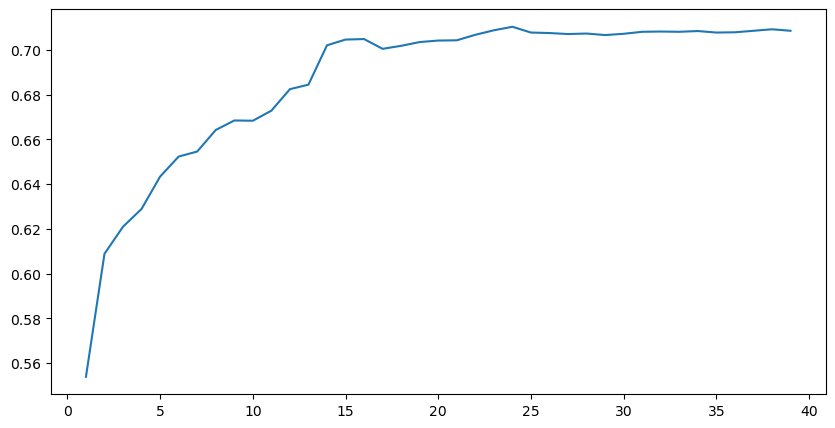

In [104]:
plt.figure(figsize=[10,5])
plt.plot(range(1, num_features[1]+1), cv_scores)
plt.show()

### the above steps can also be performed using RFECV

In [105]:
from sklearn.feature_selection import RFECV

In [106]:
rfecv = RFECV(estimator=logreg,cv=4)

In [107]:
%%time
rfecv.fit(X_train,y_train)

CPU times: total: 13.1 s
Wall time: 8.54 s


RFECV(cv=4, estimator=LogisticRegression(random_state=42))

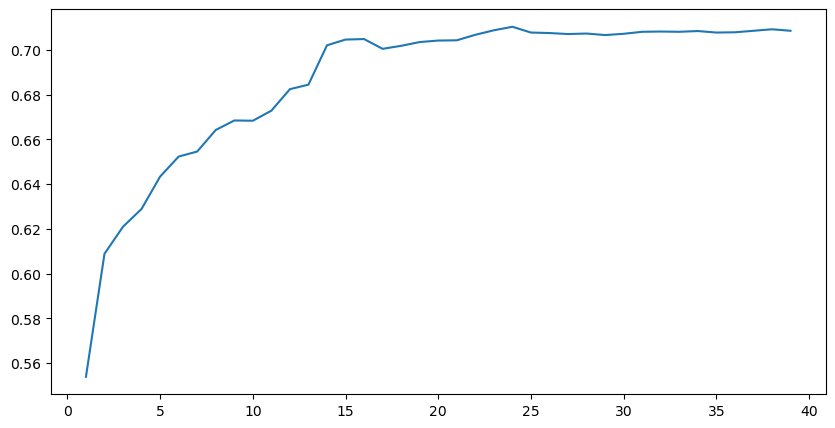

In [108]:
plt.figure(figsize=[10,5])
plt.plot(range(1, num_features[1]+1), rfecv.cv_results_["mean_test_score"])
plt.show()

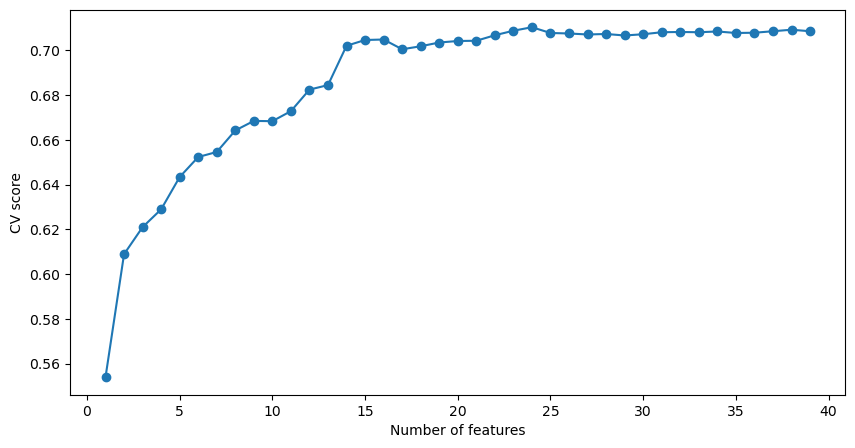

In [109]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"],
    marker="o"
)
plt.xlabel("Number of features")
plt.ylabel("CV score")
plt.show()

In [110]:
rfecv.n_features_

24

## Lets try to do some Hyperparatmeter Tuning using Cross Validation 

In [111]:
from sklearn.ensemble import RandomForestClassifier

In [112]:
from sklearn.model_selection import GridSearchCV

In [113]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1) 

In [114]:
hyper_params = {'max_depth': [3,5,10,15,20],
                'max_features':[3,5,7,11,15],
                'min_samples_leaf':[20, 50, 100, 200, 400],
                'n_estimators': [10, 25, 50, 80, 100]
                }

In [115]:
model_cv= GridSearchCV(estimator = rf,
            param_grid=hyper_params,
            verbose=1,
            cv=5,
            n_jobs=-1,
            return_train_score=True)

In [116]:
model_cv.fit(X_train,y_train)

Fitting 5 folds for each of 625 candidates, totalling 3125 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 15, 20],
                         'max_features': [3, 5, 7, 11, 15],
                         'min_samples_leaf': [20, 50, 100, 200, 400],
                         'n_estimators': [10, 25, 50, 80, 100]},
             return_train_score=True, verbose=1)

In [117]:
model_cv.best_score_

0.7181094789539556

In [126]:
model_cv.best_estimator_

RandomForestClassifier(max_depth=20, max_features=7, min_samples_leaf=20,
                       n_estimators=80, n_jobs=-1, random_state=42)

In [177]:
# model_cv.cv_results_

### Lets add this into a Dataframe and do some sorting to see nearest estimators 

In [137]:
cv_df = pd.DataFrame(model_cv.cv_results_)
cv_df.head(2)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,1.455535,0.67122,0.055192,0.032452,3,3,20,10,"{'max_depth': 3, 'max_features': 3, 'min_sampl...",0.655095,...,0.672080,0.009842,557,0.675486,0.673247,0.674507,0.670587,0.674972,0.673760,0.001752
1,0.246804,0.01473,0.069485,0.025844,3,3,20,25,"{'max_depth': 3, 'max_features': 3, 'min_sampl...",0.673012,...,0.691342,0.012256,337,0.693406,0.696066,0.697186,0.687526,0.699468,0.694731,0.004097


In [144]:
cv_df.sort_values('mean_test_score',ascending=False).head(20)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
553,1.015361,0.033377,0.127190,0.041613,20,7,20,80,"{'max_depth': 20, 'max_features': 7, 'min_samp...",0.699888,...,0.718109,0.011690,1,0.741005,0.737085,0.742125,0.741005,0.743141,0.740872,0.002054
503,0.731945,0.024388,0.115021,0.032931,20,3,20,80,"{'max_depth': 20, 'max_features': 3, 'min_samp...",0.701568,...,0.717885,0.009632,2,0.732605,0.726725,0.726445,0.726865,0.731103,0.728749,0.002583
552,0.665346,0.042389,0.100849,0.027148,20,7,20,50,"{'max_depth': 20, 'max_features': 7, 'min_samp...",0.702128,...,0.717213,0.011211,3,0.741565,0.736385,0.739325,0.742545,0.739222,0.739809,0.002139
502,0.457474,0.046113,0.086174,0.016918,20,3,20,50,"{'max_depth': 20, 'max_features': 3, 'min_samp...",0.703247,...,0.717212,0.011393,4,0.733445,0.728685,0.726865,0.726725,0.731383,0.729421,0.002622
554,1.318823,0.038687,0.157754,0.033559,20,7,20,100,"{'max_depth': 20, 'max_features': 7, 'min_samp...",0.697648,...,0.716989,0.011779,5,0.743245,0.737085,0.742685,0.741425,0.744261,0.741740,0.002501
429,0.930984,0.031613,0.087129,0.021467,15,7,20,100,"{'max_depth': 15, 'max_features': 7, 'min_samp...",0.703247,...,0.716989,0.009333,6,0.741705,0.736525,0.739745,0.740585,0.743281,0.740368,0.002257
504,0.973657,0.062655,0.127526,0.039971,20,3,20,100,"{'max_depth': 20, 'max_features': 3, 'min_samp...",0.700448,...,0.716989,0.010254,7,0.732885,0.725885,0.725745,0.726165,0.730683,0.728273,0.002953
551,0.326475,0.049249,0.093620,0.017334,20,7,20,25,"{'max_depth': 20, 'max_features': 7, 'min_samp...",0.703247,...,0.716989,0.011997,8,0.741005,0.732745,0.740865,0.742265,0.741181,0.739612,0.003469
452,0.725808,0.054231,0.103236,0.031266,15,11,20,50,"{'max_depth': 15, 'max_features': 11, 'min_sam...",0.704927,...,0.716766,0.009244,9,0.749965,0.746325,0.742545,0.745485,0.750700,0.747004,0.003003
428,0.743383,0.033757,0.116953,0.039402,15,7,20,80,"{'max_depth': 15, 'max_features': 7, 'min_samp...",0.701568,...,0.716317,0.011226,10,0.742685,0.736385,0.738625,0.738905,0.742861,0.739892,0.002510


In [155]:
sel_col=['param_max_depth', 'param_max_features', 'param_min_samples_leaf', 'param_n_estimators','rank_test_score', 'mean_train_score', 'mean_test_score']

In [157]:
cv_df.sort_values('rank_test_score',ascending=True)[sel_col].head(20)

,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,rank_test_score,mean_train_score,mean_test_score
553,20,7,20,80,1,0.740872,0.718109
503,20,3,20,80,2,0.728749,0.717885
552,20,7,20,50,3,0.739809,0.717213
502,20,3,20,50,4,0.729421,0.717212
554,20,7,20,100,5,0.741740,0.716989
429,15,7,20,100,6,0.740368,0.716989
504,20,3,20,100,7,0.728273,0.716989
551,20,7,20,25,8,0.739612,0.716989
452,15,11,20,50,9,0.747004,0.716766
428,15,7,20,80,10,0.739892,0.716317


#### We can see there is no much difference between all the results above - so based on our objectives we can select the no of depth,features etc

## Effect of Hyper-Parameters (how the parameters affecting our output)

In [179]:
cv_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_max_depth', 'param_max_features', 'param_min_samples_leaf',
       'param_n_estimators', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score', 'split0_train_score', 'split1_train_score',
       'split2_train_score', 'split3_train_score', 'split4_train_score',
       'mean_train_score', 'std_train_score'],
      dtype='object')

In [186]:
cv_df.groupby('param_max_depth')[['mean_train_score', 'mean_test_score']] .mean()

,mean_train_score,mean_test_score
param_max_depth,,
3,0.685304,0.681509
5,0.697049,0.691993
10,0.704985,0.695964
15,0.707309,0.696413
20,0.707703,0.696507


##### Lets select the max depth and see how the mean value is represented 

<Axes: xlabel='param_max_depth'>

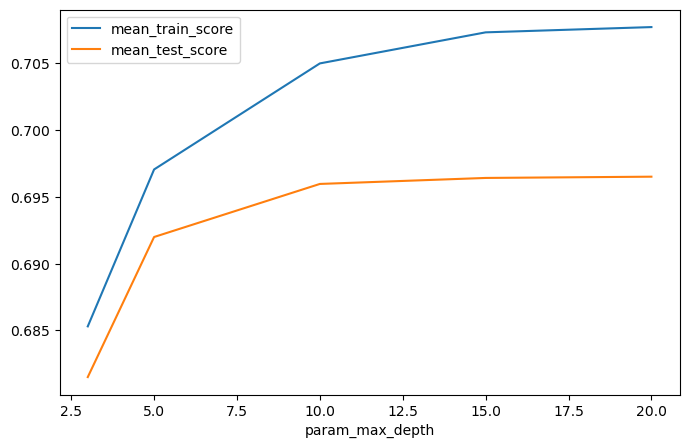

In [185]:
cv_df.groupby('param_max_depth')[['mean_train_score', 'mean_test_score']] .mean().plot(figsize=(8,5))

##### Lets see the median score also following mean score

<Axes: xlabel='param_max_depth'>

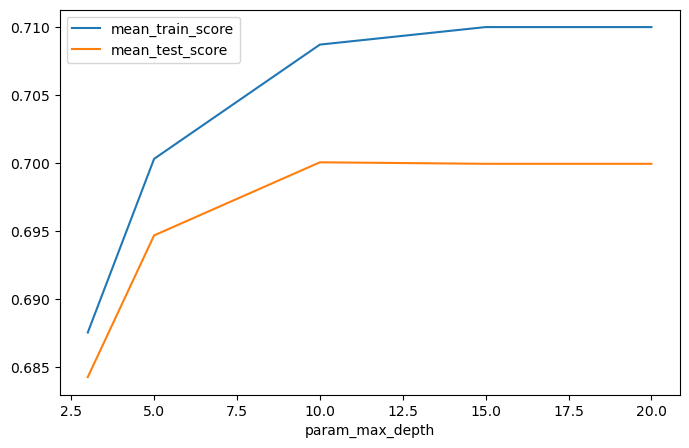

In [188]:
cv_df.groupby('param_max_depth')[['mean_train_score', 'mean_test_score']].agg(np.median).plot(figsize=(8,5))

<Axes: xlabel='param_n_estimators'>

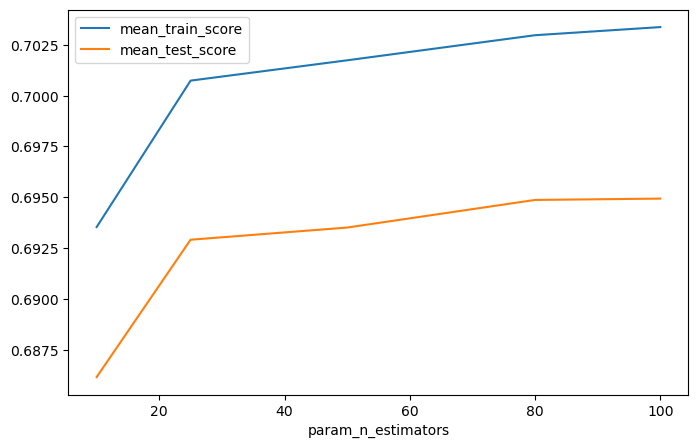

In [190]:
cv_df.groupby('param_n_estimators')[['mean_train_score', 'mean_test_score']].agg(np.mean).plot(figsize=(8,5))

<Axes: xlabel='param_max_features'>

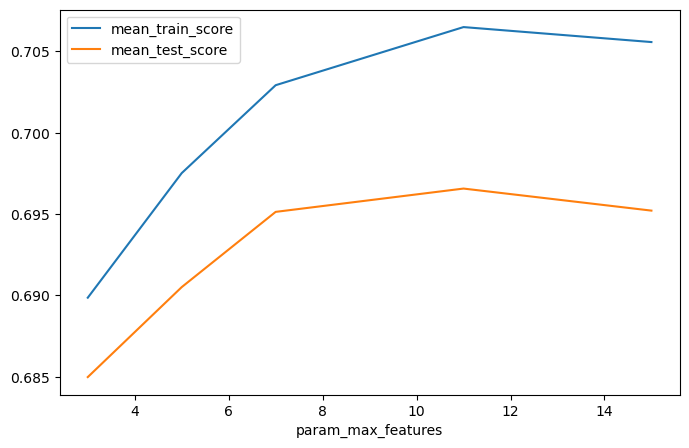

In [191]:
cv_df.groupby('param_max_features')[['mean_train_score', 'mean_test_score']].agg(np.mean).plot(figsize=(8,5))

<Axes: xlabel='param_max_features'>

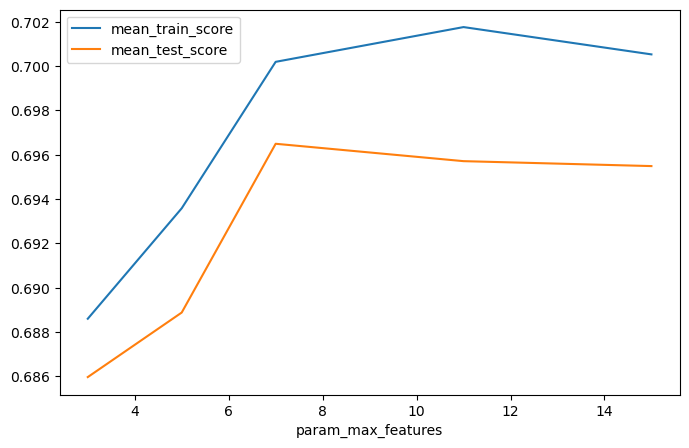

In [192]:
cv_df.groupby('param_max_features')[['mean_train_score', 'mean_test_score']].agg(np.median).plot(figsize=(8,5))

<Axes: xlabel='param_min_samples_leaf'>

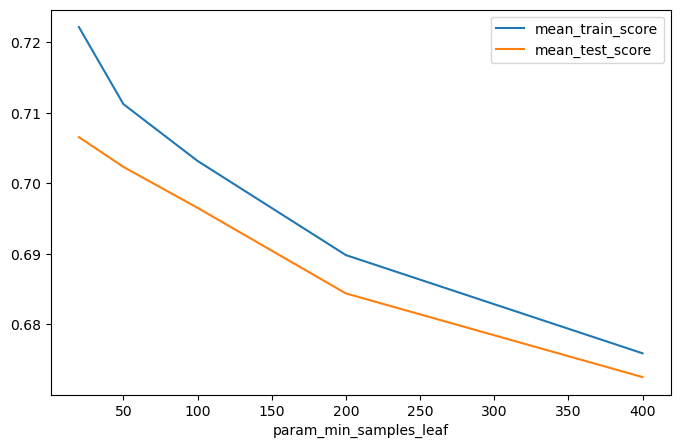

In [193]:
cv_df.groupby('param_min_samples_leaf')[['mean_train_score', 'mean_test_score']].agg(np.mean).plot(figsize=(8,5))

<Axes: xlabel='param_min_samples_leaf'>

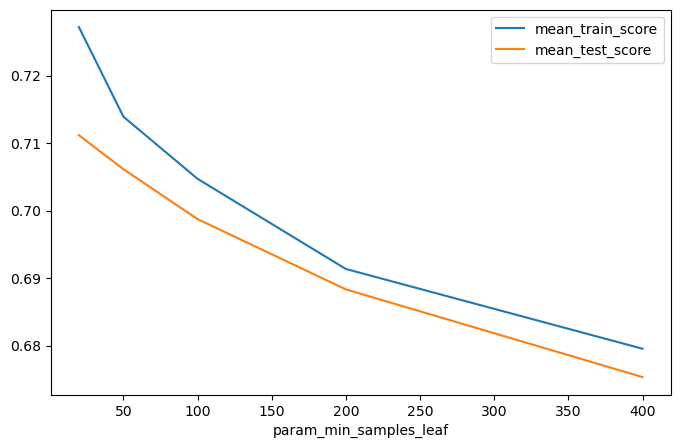

In [194]:
cv_df.groupby('param_min_samples_leaf')[['mean_train_score', 'mean_test_score']].agg(np.median).plot(figsize=(8,5))

### Now lets move to the Fine tuning using Grid Search 

In [205]:
hyper_parameters = { 'min_samples_leaf': [5,10,20, 50],
                    'n_estimators' : [50, 60, 70],
                    'max_features' : [10, 12, 14, 16]
                   }

In [206]:
rf = RandomForestClassifier(max_depth=12, random_state =42, n_jobs=-1)

In [207]:
model_cv2 = GridSearchCV(estimator = rf,
            param_grid=hyper_parameters,
            verbose=1,
            cv=5,
            n_jobs=-1,
            return_train_score=True)

In [208]:
model_cv2.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=12, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_features': [10, 12, 14, 16],
                         'min_samples_leaf': [5, 10, 20, 50],
                         'n_estimators': [50, 60, 70]},
             return_train_score=True, verbose=1)

In [209]:
model_cv2.best_score_

0.7204610399590968

In [214]:
model_cv2.best_estimator_

RandomForestClassifier(max_depth=12, max_features=14, min_samples_leaf=10,
                       n_estimators=60, n_jobs=-1, random_state=42)

So, in the video, you saw the effect of each of the hyperparameters plotted with different values against the mean of both the train and test scores. But in the case of extreme values, the mean may not be the best method to compare the model scores. In such cases, you can choose the median, which is more robust against such anomalies and you can get a general idea of how your model is performing. All these steps that we covered till now using GridSearchCV are collectively referred to as coarse tuning. The plots helped you identify a narrow range of hyperparameter values.

## Lets see how Randomized Search CV works 

In [215]:
from sklearn.model_selection import RandomizedSearchCV

In [216]:
hyper_params = {'max_depth': range(3,20),
               'max_features': range(3,17),
               'min_samples_leaf': range (20, 400,50),
               'n_estimators': range(10,101,10)}

In [217]:
model_rcv = RandomizedSearchCV(estimator = rf,
                              param_distributions=hyper_params,
                              verbose=1,
                              cv=5,
                              return_train_score=True,
                              n_jobs=-1,
                              n_iter=50)

In [218]:
model_rcv.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(max_depth=12, n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': range(3, 20),
                                        'max_features': range(3, 17),
                                        'min_samples_leaf': range(20, 400, 50),
                                        'n_estimators': range(10, 101, 10)},
                   return_train_score=True, verbose=1)

In [219]:
model_rcv.best_score_

0.7159807528834603

In [221]:
model_cv.best_score_

0.7181094789539556

In [220]:
model_rcv.best_estimator_

RandomForestClassifier(max_depth=18, max_features=8, min_samples_leaf=20,
                       n_estimators=80, n_jobs=-1, random_state=42)

## Now lets move to the Fine tuning using Randomized Search CV

In [227]:
hyper_parameter = {'min_samples_leaf': range (5,10,50),
                   'n_estimators': range(10,21,100),
                   'max_features': range(3,12, 14)
                  }

In [230]:
model_rcv2 = RandomizedSearchCV(estimator = rf,
                              param_distributions=hyper_parameter,
                              verbose=1,
                              cv=5,
                              return_train_score=True,
                              n_jobs=-1,
                              n_iter=50)

In [231]:
model_rcv2.fit(X_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(max_depth=12, n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_features': range(3, 12, 14),
                                        'min_samples_leaf': range(5, 10, 50),
                                        'n_estimators': range(10, 21, 100)},
                   return_train_score=True, verbose=1)

In [232]:
model_rcv2.best_score_

0.7110536667074445

In [233]:
model_rcv2.best_estimator_

RandomForestClassifier(max_depth=12, max_features=3, min_samples_leaf=5,
                       n_estimators=10, n_jobs=-1, random_state=42)

### Now lets move to the next step 
## Extracting the best model and lets see their Test performance 

In [238]:
print(model_cv.best_score_, model_cv2.best_score_, model_rcv.best_score_, model_rcv2.best_score_)

0.7181094789539556 0.7204610399590968 0.7110536667074445 0.7110536667074445


#### We can see Fine tuning using Grid search is the best across all the 4 result 

Lets take the Model_cv2 model and test that in the unseen data 

In [241]:
rf_best = model_cv2.best_estimator_
rf_best

RandomForestClassifier(max_depth=12, max_features=14, min_samples_leaf=10,
                       n_estimators=60, n_jobs=-1, random_state=42)

Lets go and test this on the test set 

In [242]:
y_test_pred = rf_best.predict(X_test)

In [243]:
accuracy_score (y_test, y_test_pred)

0.7075682937751904